In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [ ]:
df = pd.read_csv("data/swach_sense_synthetic_dataset-1.csv")
df = df.drop(columns=["timestamp"])

In [3]:
# Normalization for gas sensors
gas_scaler = MinMaxScaler()

df[["mq35_norm", "mq36_norm"]] = gas_scaler.fit_transform(
    df[["mq35", "mq36"]]
)

# Gas Ratio Feature
df["gas_ratio"] = df["mq35"] / (df["mq36"] + 1e-6)

In [4]:
features = [
    "mq35_norm",
    "mq36_norm",
    "gas_ratio",
    "temp_C",
    "humidity"
]

X = df[features]
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.982


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [8]:
print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.997

Confusion Matrix:
[[439   0   1]
 [  0 320   0]
 [  1   1 238]]

Classification Report:
              precision    recall  f1-score   support

       CLEAN       1.00      1.00      1.00       440
   HAZARDOUS       1.00      1.00      1.00       320
    MODERATE       1.00      0.99      0.99       240

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [9]:
joblib.dump(rf_model, "swachsense_model.pkl")
joblib.dump(gas_scaler, "gas_scaler.pkl")

print("\nModel exported successfully!")


Model exported successfully!


In [ ]:
import joblib
import numpy as np

# Load model and scaler
model = joblib.load("swachsense_model.pkl")
scaler = joblib.load("gas_scaler.pkl")


def predict_hygiene_state(mq35, mq36, temperature, humidity):

    # normalize gases
    norm_values = scaler.transform([[mq35, mq36]])
    mq35_norm, mq36_norm = norm_values[0]

    # gas ratio
    gas_ratio = mq35 / (mq36 + 1e-6)

    features = np.array([[
        mq35_norm,
        mq36_norm,
        gas_ratio,
        temperature,
        humidity
    ]])

    prediction = model.predict(features)[0]

    return prediction

In [11]:
state = predict_hygiene_state(
    mq35=180,
    mq36=120,
    temperature=27,
    humidity=65
)

print("Predicted Hygiene State:", state)

Predicted Hygiene State: MODERATE


c:\Users\Krushna Keshab Jena\Desktop\swachha sense\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Krushna Keshab Jena\Desktop\swachha sense\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd

df = pd.read_csv("swach_sense_synthetic_dataset-1.csv")

# Remove timestamp
df = df.drop(columns=["timestamp"])

# Group by label and check statistics
thresholds = df.groupby("label").agg(["min", "max", "mean", "std"])

print(thresholds)

          mq35                             mq36                              \
           min  max        mean        std  min  max        mean        std   
label                                                                         
CLEAN        1  198   99.180909  24.940128   10  144   79.994091  19.995485   
HAZARDOUS  186  585  383.218750  62.008702  107  526  311.621875  54.639338   
MODERATE    93  364  218.742500  41.276963   67  306  178.952500  34.426897   

          mq37                             temp_C                             \
           min  max        mean        std    min   max       mean       std   
label                                                                          
CLEAN       11  126   69.100909  17.824693   20.0  32.8  25.982318  1.943764   
HAZARDOUS   88  427  268.563125  50.896353   25.4  41.0  32.025000  2.078452   
MODERATE    71  253  159.455833  30.118111   22.4  34.6  28.860667  1.926728   

          humidity                          

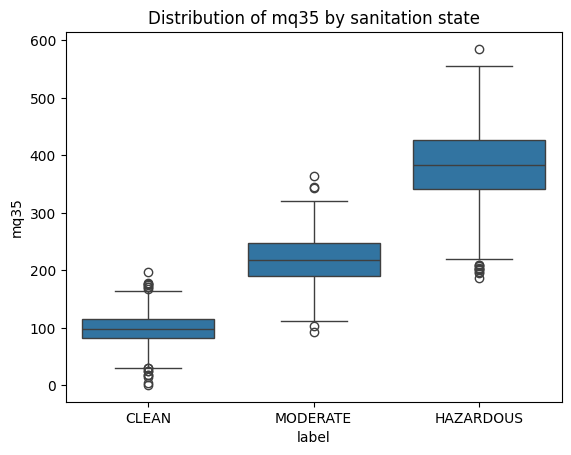

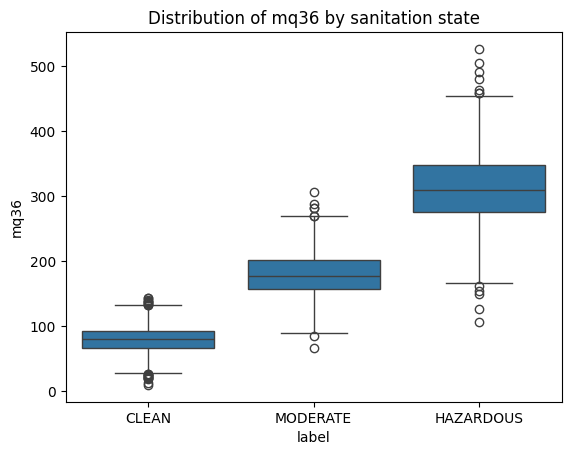

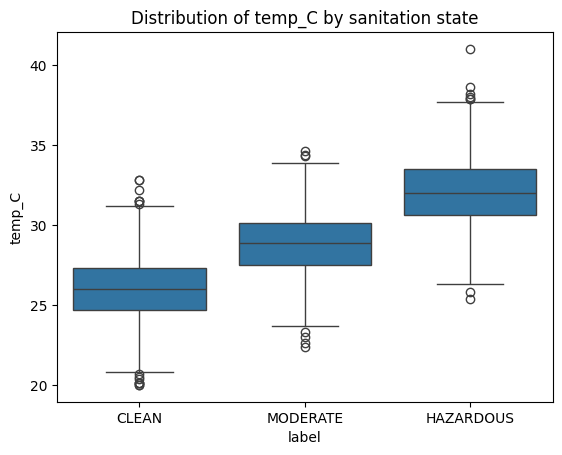

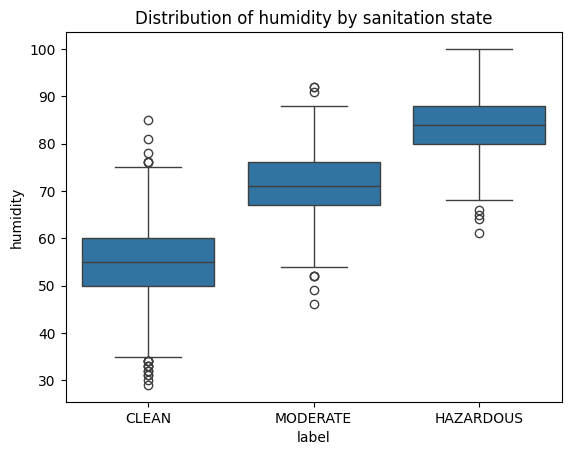

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["mq35", "mq36", "temp_C", "humidity"]

for f in features:
    sns.boxplot(x="label", y=f, data=df)
    plt.title(f"Distribution of {f} by sanitation state")
    plt.show()